<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 140 &#183; Extended Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Forecasting with Drivers</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:760px;line-height:1.6">A time-series forecast that uses outside information, not just the past of the series. We forecast daily demand with SARIMAX, feeding it the drivers a business actually knows in advance, weather, promotions, and holidays, and show it beats a pure time-series model by half.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 1 &#183; FRAME</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Forecast a number the drivers can explain</div>
<div style="color:#4a5578;margin-top:6px">Demand is not just its own past, it responds to weather and marketing.</div>
</div>

A store needs a daily forecast of how many units it will sell, to stock shelves and staff shifts. Pure time-series models (ARIMA and friends) forecast the future purely from the past of the series. But demand here is pushed around by things the business already knows or plans: the weather, whether the product is on **promotion**, and the **holiday** calendar. A model that is blind to those cannot anticipate a heat-wave spike or a promotion. The tool that fixes this is **SARIMAX**, ARIMA plus e**X**ogenous drivers, also called *regression with ARIMA errors*.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 2 &#183; DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two years of daily demand, plus its drivers</div>
<div style="color:#4a5578;margin-top:6px">One row per day, no gaps.</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings('ignore')
EM='#0284c7'; DEEP='#0369a1'; LIGHT='#bae6fd'; INK='#1a2138'; GRID='#e6e9f2'; RED='#ef4444'; GREEN='#059669'; AMBER='#d97706'; GREY='#94a3b8'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','figure.dpi':110,'font.size':11,
   'axes.edgecolor':GRID,'axes.grid':True,'grid.color':GRID,'axes.axisbelow':True,'axes.spines.top':False,
   'axes.spines.right':False,'axes.titlesize':12,'axes.titleweight':'bold','legend.frameon':False})
BASE='https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/'
try:    df = pd.read_excel('../../data/ch140_daily_demand.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE+'ch140_daily_demand.xlsx', sheet_name='Data')
df['date'] = pd.to_datetime(df['date']); df = df.set_index('date').asfreq('D')
print(f"{len(df)} days: {df.index.min().date()} to {df.index.max().date()}")
print(f"units/day: mean {df.units_sold.mean():.0f}, range {df.units_sold.min()}-{df.units_sold.max()} | promo days {int(df.on_promotion.sum())} | holidays {int(df.is_holiday.sum())}")
df.head(4)

730 days: 2023-01-01 to 2024-12-30
units/day: mean 238, range 156-351 | promo days 95 | holidays 24


,units_sold,temperature_c,on_promotion,is_holiday,day_of_week
date,,,,,
2023-01-01,221,1.7,0,0,Sunday
2023-01-02,197,6.4,0,0,Monday
2023-01-03,253,1.6,1,0,Tuesday
2023-01-04,204,7.4,0,0,Wednesday


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 3 &#183; EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">See the rhythms and the shocks</div>
<div style="color:#4a5578;margin-top:6px">A weekly cycle, a yearly swing, and promo spikes.</div>
</div>

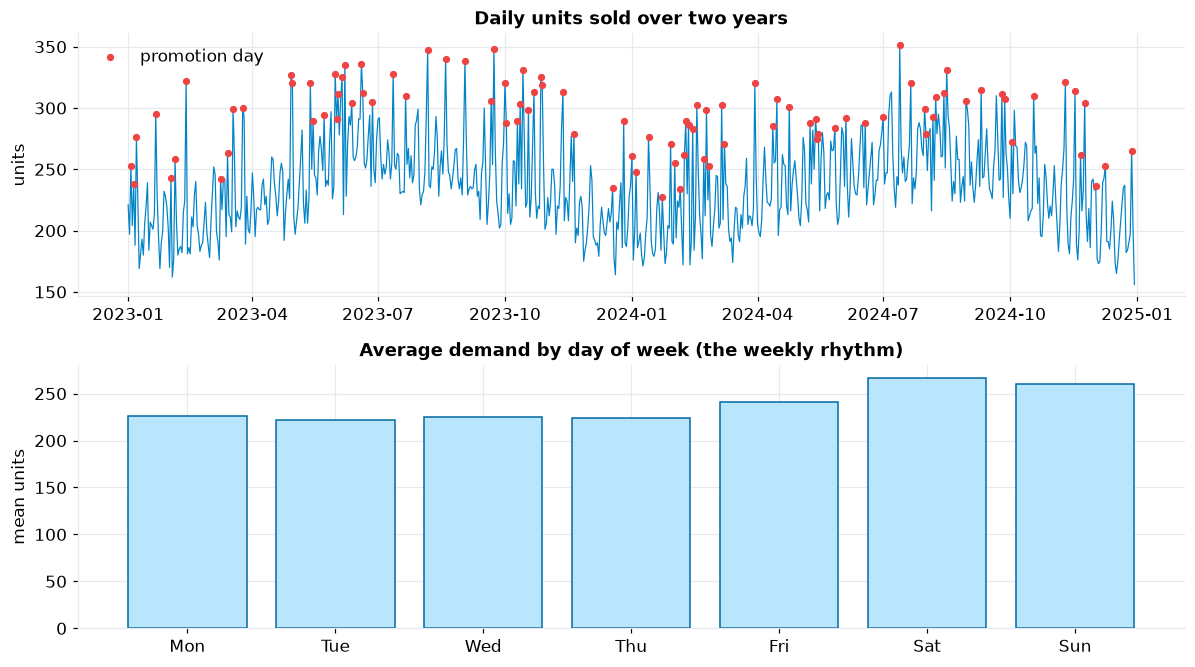

correlation of demand with temperature: 0.55
mean units on promo vs off: 294 vs 229


In [2]:
fig, ax = plt.subplots(2, 1, figsize=(11,6.2))
ax[0].plot(df.index, df.units_sold, color=EM, lw=0.8)
pr = df[df.on_promotion==1]
ax[0].scatter(pr.index, pr.units_sold, s=14, color=RED, zorder=3, label='promotion day')
ax[0].set(title='Daily units sold over two years', ylabel='units'); ax[0].legend(loc='upper left')
# average by day of week
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wk = df.groupby('day_of_week').units_sold.mean().reindex(order)
ax[1].bar(range(7), wk.values, color=LIGHT, edgecolor=DEEP)
ax[1].set_xticks(range(7)); ax[1].set_xticklabels([d[:3] for d in order])
ax[1].set(title='Average demand by day of week (the weekly rhythm)', ylabel='mean units')
plt.tight_layout(); plt.show()
print('correlation of demand with temperature: %.2f' % df.units_sold.corr(df.temperature_c))
print('mean units on promo vs off: %.0f vs %.0f' % (df[df.on_promotion==1].units_sold.mean(), df[df.on_promotion==0].units_sold.mean()))

Three patterns jump out, and each points to a driver. There is a smooth **yearly swing** (demand rises through the warm months, correlation with temperature about 0.55), a strong **weekly rhythm** (weekends far higher), and sharp **upward spikes** that line up with promotion days. A pure ARIMA can learn the first two from the shape of the series, but the promotion spikes are effectively random from the series' own point of view, you can only anticipate them if you feed the model the promotion calendar.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 4 &#183; SPLIT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Hold out the most recent days, never shuffle</div>
<div style="color:#4a5578;margin-top:6px">Time-series validation respects the arrow of time.</div>
</div>

In [3]:
H = 90                       # forecast horizon / test window = last 90 days
train, test = df.iloc[:-H], df.iloc[-H:]
y_tr, y_te = train.units_sold.astype(float), test.units_sold.astype(float)
print(f"train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"test : {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")
print('We forecast the test window and score against what actually happened. A random split would leak the future into the past.')

train: 2023-01-01 to 2024-10-01 (640 days)
test : 2024-10-02 to 2024-12-30 (90 days)
We forecast the test window and score against what actually happened. A random split would leak the future into the past.


For time series you never shuffle. We train on the first ~640 days and hold out the final **90 days** as an honest test of forecasting into the unknown. A random train/test split, standard for non-temporal data, would let the model peek at future days while learning the past, flattering its score and lying about how it will do in production.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 5 &#183; BASELINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Seasonal-naive: yesterday-of-last-week</div>
<div style="color:#4a5578;margin-top:6px">The bar a real model must clear.</div>
</div>

In [4]:
def scores(actual, forecast):
    a, f = np.asarray(actual, float), np.asarray(forecast, float)
    return dict(MAE=np.mean(np.abs(a-f)), RMSE=np.sqrt(np.mean((a-f)**2)), MAPE=np.mean(np.abs((a-f)/a))*100)
snaive = df.units_sold.shift(7).iloc[-H:]      # predict each day as the same weekday one week earlier
s_base = scores(y_te, snaive)
print('seasonal-naive:  MAE %(MAE).1f   RMSE %(RMSE).1f   MAPE %(MAPE).1f%%' % s_base)
print('Because the weekly cycle is strong, last week is a surprisingly tough baseline to beat.')

seasonal-naive:  MAE 23.3   RMSE 31.1   MAPE 10.8%
Because the weekly cycle is strong, last week is a surprisingly tough baseline to beat.


The **seasonal-naive** forecast just repeats the value from the same weekday a week ago. On strongly weekly data this is a genuinely tough baseline, here it is off by about **23 units a day**. Any model we build has to beat it to be worth the trouble.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 6 &#183; CALENDAR MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A time-series model that knows the calendar but not the drivers</div>
<div style="color:#4a5578;margin-top:6px">Regression with ARIMA errors, part one.</div>
</div>

We model the weekly cycle explicitly with **day-of-week dummy variables** and let an **AR(1)** term mop up the leftover day-to-day correlation, this is SARIMAX with `order=(1,0,0)` and calendar dummies as exogenous inputs. Crucially, this first model gets the calendar but **not** the business drivers, so we can isolate exactly what the drivers add.

In [5]:
DOW = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
def dow_dummies(idx):
    d = pd.get_dummies(pd.Categorical(idx.day_name(), categories=DOW), drop_first=True).astype(float)
    d.index = idx; d.columns = ['dow_'+c[:3] for c in DOW[1:]]
    return d
cal = dow_dummies(df.index)                                   # 6 day-of-week dummies (Monday is the baseline)
drivers = df[['temperature_c','on_promotion','is_holiday']].astype(float)
m_cal = SARIMAX(y_tr, exog=cal.iloc[:-H], order=(1,0,0), trend='c',
                enforce_stationarity=True, enforce_invertibility=True).fit(disp=0)
f_cal = m_cal.forecast(H, exog=cal.iloc[-H:])
s_cal = scores(y_te, f_cal)
print('calendar-only SARIMAX:  MAE %(MAE).1f   RMSE %(RMSE).1f   MAPE %(MAPE).1f%%' % s_cal)

calendar-only SARIMAX:  MAE 27.7   RMSE 33.5   MAPE 13.3%


A model that knows only the weekly rhythm scores about **28**, actually a touch **worse** than the naive baseline. That is the key setup: capturing the calendar is not enough, because it cannot see the weather warming up or a promotion coming. For that, the model needs the drivers.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 7 &#183; SARIMAX + DRIVERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Feed in weather, promotions, and holidays</div>
<div style="color:#4a5578;margin-top:6px">The full model.</div>
</div>

In [6]:
exog_full = pd.concat([drivers, cal], axis=1)                 # business drivers + calendar
m_full = SARIMAX(y_tr, exog=exog_full.iloc[:-H], order=(1,0,0), trend='c',
                 enforce_stationarity=True, enforce_invertibility=True).fit(disp=0)
f_full = m_full.forecast(H, exog=exog_full.iloc[-H:])
s_full = scores(y_te, f_full)
print('SARIMAX + drivers:  MAE %(MAE).1f   RMSE %(RMSE).1f   MAPE %(MAPE).1f%%' % s_full)

SARIMAX + drivers:  MAE 11.5   RMSE 13.8   MAPE 5.3%


Adding the three drivers transforms the forecast: the daily error drops to about **11.5 units**, a **MAPE near 5%**. Same ARIMA machinery, same horizon, the only change is that the model can now see the weather, the promotions, and the holidays, exactly the information a planner has in hand.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 8 &#183; EVALUATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Line up all three on the held-out days</div>
<div style="color:#4a5578;margin-top:6px">The picture that makes the case.</div>
</div>

                    MAE  RMSE  MAPE
seasonal-naive     23.3  31.1  10.8
calendar-only      27.7  33.5  13.3
SARIMAX + drivers  11.5  13.8   5.3

drivers cut MAE by 51% vs naive and 59% vs calendar-only.


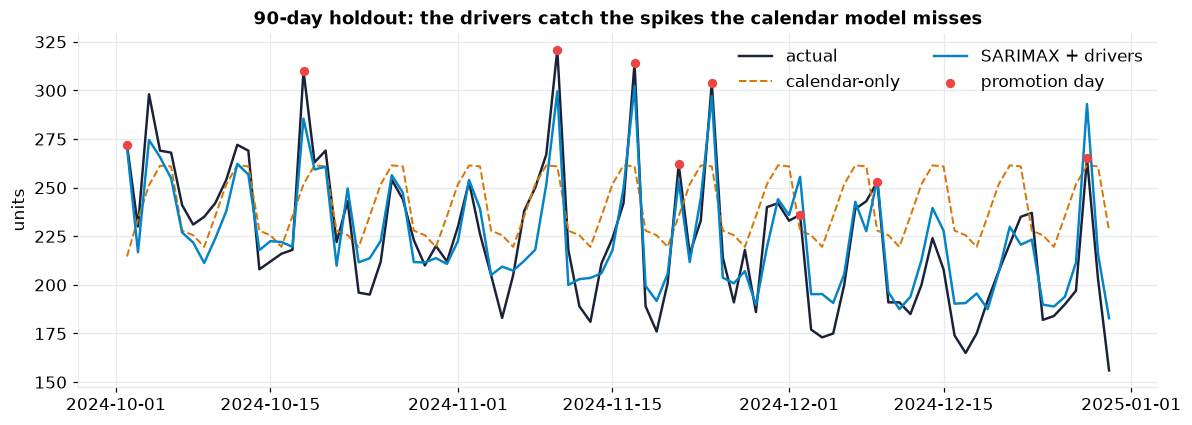

In [7]:
tab = pd.DataFrame({'seasonal-naive':s_base, 'calendar-only':s_cal, 'SARIMAX + drivers':s_full}).T
print(tab.round(1).to_string())
print('\ndrivers cut MAE by %.0f%% vs naive and %.0f%% vs calendar-only.' % ((1-s_full['MAE']/s_base['MAE'])*100, (1-s_full['MAE']/s_cal['MAE'])*100))
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(test.index, y_te, color=INK, lw=1.6, label='actual')
ax.plot(test.index, f_cal, color=AMBER, lw=1.3, ls='--', label='calendar-only')
ax.plot(test.index, f_full, color=EM, lw=1.6, label='SARIMAX + drivers')
pr_te = test[test.on_promotion==1]
ax.scatter(pr_te.index, pr_te.units_sold, s=26, color=RED, zorder=4, label='promotion day')
ax.set(title='90-day holdout: the drivers catch the spikes the calendar model misses', ylabel='units'); ax.legend(ncol=2)
plt.tight_layout(); plt.show()

The table and the plot tell the same story. The calendar-only forecast (amber) tracks the weekly wiggle but sails straight past every promotion spike; the driver model (blue) rides right on top of the actual line, catching the spikes because it was told when promotions happen. Against the naive baseline the drivers cut the average error by about **half**.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 9 &#183; COEFFICIENTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Read the drivers' effects, with confidence intervals</div>
<div style="color:#4a5578;margin-top:6px">The model is also an explanation.</div>
</div>

In [8]:
ci = m_full.conf_int()
for name, label in [('temperature_c','per +1 degree C'), ('on_promotion','a promotion day'), ('is_holiday','a holiday')]:
    lo, hi = ci.loc[name]
    print(f'{label:16s}: {m_full.params[name]:+6.1f} units   95% CI [{lo:+.1f}, {hi:+.1f}]   p={m_full.pvalues[name]:.1e}')
print(f"\nAR(1) coefficient: {m_full.params['ar.L1']:+.2f}  (day-to-day carryover in the residual)")

per +1 degree C :   +2.7 units   95% CI [+2.5, +2.9]   p=2.5e-136
a promotion day :  +58.8 units   95% CI [+56.4, +61.2]   p=0.0e+00
a holiday       :  +32.4 units   95% CI [+27.4, +37.5]   p=2.5e-36

AR(1) coefficient: +0.51  (day-to-day carryover in the residual)


Because SARIMAX is a regression, its exogenous coefficients are directly interpretable. Each degree Celsius warmer adds about **2.7 units**; a **promotion adds about 59 units** a day; a **holiday adds about 32**. All three are overwhelmingly significant, and their confidence intervals are tight and comfortably recover the effects built into the data. A pure ARIMA gives you a forecast; SARIMAX gives you a forecast **and** a quantified reason for it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 10 &#183; DIAGNOSTICS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Are the residuals just noise now?</div>
<div style="color:#4a5578;margin-top:6px">Check what the model has not explained.</div>
</div>

Ljung-Box test for leftover autocorrelation:
    lb_stat  lb_pvalue
7   20.4201     0.0047
14  36.9578     0.0007

AIC  calendar-only 6243  vs  SARIMAX+drivers 4987  (lower is better)


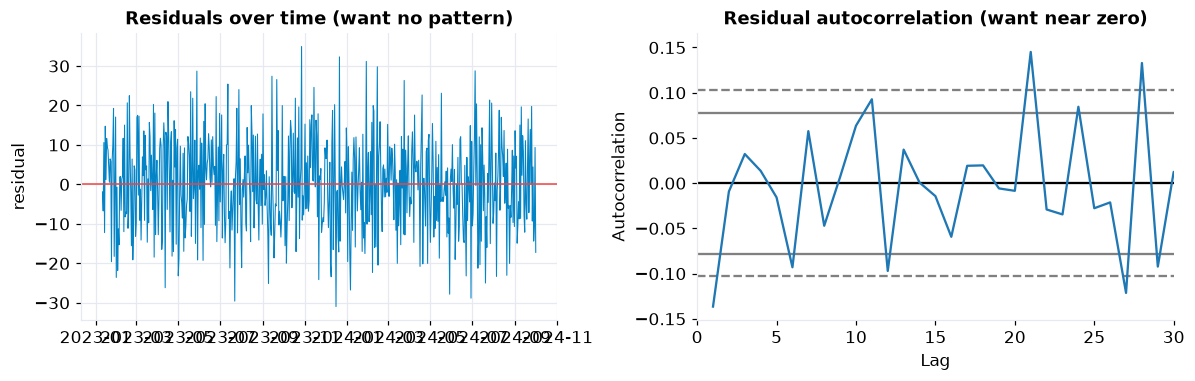

In [9]:
resid = m_full.resid[10:]                      # drop the state-space burn-in
lb = acorr_ljungbox(resid, lags=[7,14], return_df=True)
print('Ljung-Box test for leftover autocorrelation:'); print(lb.round(4).to_string())
print(f"\nAIC  calendar-only {m_cal.aic:.0f}  vs  SARIMAX+drivers {m_full.aic:.0f}  (lower is better)")
fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
ax[0].plot(resid.index, resid, color=EM, lw=0.7); ax[0].axhline(0, color=RED, lw=1)
ax[0].set(title='Residuals over time (want no pattern)', ylabel='residual')
pd.plotting.autocorrelation_plot(resid, ax=ax[1]); ax[1].set_xlim(0,30)
ax[1].set(title='Residual autocorrelation (want near zero)')
plt.tight_layout(); plt.show()

The residuals look like noise: no trend, no seasonal ripple, and the autocorrelation is tiny. The AIC has dropped sharply from the calendar-only model, more explained, not just more parameters. Being honest, with 640 observations the **Ljung-Box** test is powerful enough to flag a whisp of leftover autocorrelation (p near 0.001); it is practically negligible here, but in production you might add a second AR lag or a short seasonal term to tidy it up. Diagnostics matter even when the forecast is already good.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 11 &#183; FORECAST THE FUTURE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">To use drivers, you must supply the future drivers</div>
<div style="color:#4a5578;margin-top:6px">The catch, and how to handle it.</div>
</div>

Here is the crucial difference from a pure ARIMA. To forecast tomorrow, SARIMAX needs tomorrow's **driver values**. Two of ours are known in advance, the promotion schedule and the holiday calendar are things the business plans, but **temperature has to itself be forecast**. So we build a future scenario: the planned promotions and holidays, plus a temperature forecast (here, the seasonal normal). Uncertainty in the weather forecast becomes uncertainty in the demand forecast, which the prediction interval reflects.

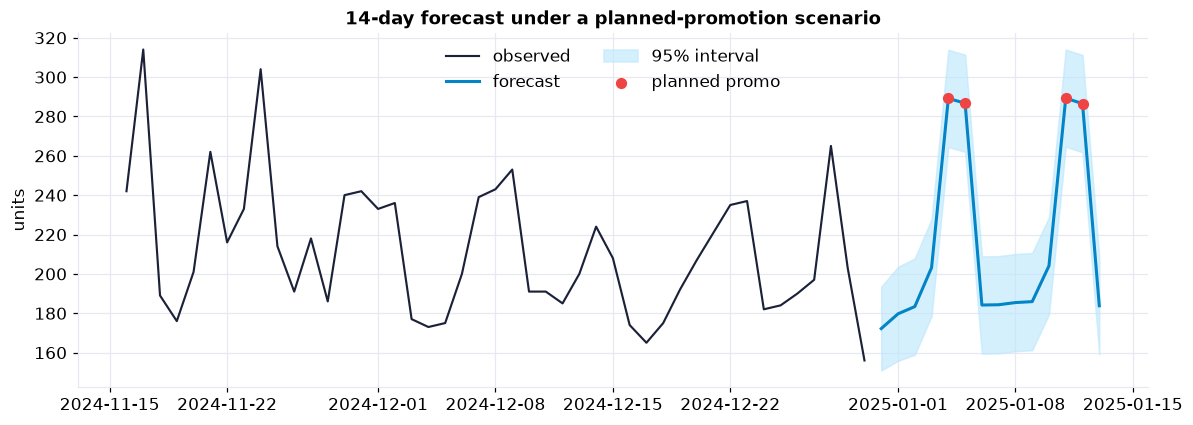

planned promo days lift the forecast by about 64 units each, visible as the red bumps.


In [10]:
# refit on ALL data, then forecast the next 14 days under a planned scenario
# (seed the optimizer with the training-model parameters so the full-data fit lands at the same, best optimum)
m_all = SARIMAX(df.units_sold.astype(float), exog=exog_full, order=(1,0,0), trend='c',
                enforce_stationarity=True, enforce_invertibility=True).fit(start_params=m_full.params, disp=0)
future = pd.date_range(df.index.max()+pd.Timedelta(days=1), periods=14, freq='D')
temp_normal = 14 + 11*np.sin(2*np.pi*(np.arange(len(df), len(df)+14)-110)/365.25)   # seasonal-normal temp forecast
plan_promo = np.zeros(14, int); plan_promo[[4,5,11,12]] = 1     # a planned weekend promotion, twice
plan_hol   = np.zeros(14, int)
fut_drivers = pd.DataFrame({'temperature_c':temp_normal,'on_promotion':plan_promo,'is_holiday':plan_hol}, index=future)
fut_exog = pd.concat([fut_drivers, dow_dummies(future)], axis=1)[exog_full.columns]
fc = m_all.get_forecast(14, exog=fut_exog); mean, cint = fc.predicted_mean, fc.conf_int()
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(df.index[-45:], df.units_sold.iloc[-45:], color=INK, lw=1.4, label='observed')
ax.plot(future, mean, color=EM, lw=2, label='forecast')
ax.fill_between(future, cint.iloc[:,0], cint.iloc[:,1], color=LIGHT, alpha=0.6, label='95% interval')
ax.scatter(future[plan_promo==1], mean[plan_promo==1], s=40, color=RED, zorder=5, label='planned promo')
ax.set(title='14-day forecast under a planned-promotion scenario', ylabel='units'); ax.legend(ncol=2)
plt.tight_layout(); plt.show()
print('planned promo days lift the forecast by about %.0f units each, visible as the red bumps.' % m_all.params['on_promotion'])

The forecast shows the planned promotion days as clear bumps, the model turns a marketing plan into a demand number the operations team can stock against. The shaded band is the 95% interval; it would widen further if we admitted that the temperature itself is only forecast, not known. This is the honest reality of driver-based forecasting: the forecast is only as good as the driver assumptions you feed it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the operations team</div>
<div style="color:#4a5578;margin-top:6px">Plain English, decision-ready.</div>
</div>

**For the operations team:** We built a daily demand forecast that uses the information you already plan around, the promotion schedule, the holiday calendar, and the weather outlook, on top of the normal weekly rhythm. On the most recent three months it predicted demand to within about **5%** on an average day, roughly **half the error** of a model that ignores those drivers. It also quantifies them: a promotion adds about **59 units** a day, a holiday about **32**, and each degree of warmth about **2.7**. Two cautions: to forecast ahead we must supply the future drivers, so a promotion plan and a weather outlook are inputs, not outputs, and the forecast is only as reliable as those assumptions. We recommend using it for stocking and staffing, and revisiting it whenever the promotion plan changes.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>